In [1]:
# >>> repo-root chdir setup >>>
import os
from pathlib import Path
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    return start
_root = _find_repo_root(Path(os.getcwd()).resolve())
if Path(os.getcwd()).resolve() != _root:
    os.chdir(_root)
print('CWD:', os.getcwd())
# <<< repo-root chdir setup <<<


CWD: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


# Data-Leakage Validation Audit — Clean Pipeline

Reproduces the five checks in `tests/test_data_leakage_clean_pipeline.py` in a readable, plot-friendly form, and emits:

- `figures/validation/capture_overlap_matrix.png`
- `artifacts/validation/data_leakage_summary.json` and `.csv`

**All inputs come from the current clean-pipeline artifacts only.**

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.clean_pipeline.validation import (
    FORBIDDEN_FEATURE_SUBSTRINGS,
    METADATA_COLS,
    capture_overlap_matrix,
    ensure_policy_threshold_provenance,
    ensure_preprocessing_metadata,
    hash_feature_rows,
    load_features_dataframe,
    load_split_capture_sets,
    locate_clean_artifacts,
    model_feature_columns,
)

from src.clean_pipeline.validation.preprocessing_metadata import stats_match_train

paths = locate_clean_artifacts()
paths.assert_minimum_present()

print("Repo:", paths.repo_root)

Repo: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


## 1 · Capture-level split overlap

       train  val  test
train    244    0     0
val        0   16     0
test       0    0    80


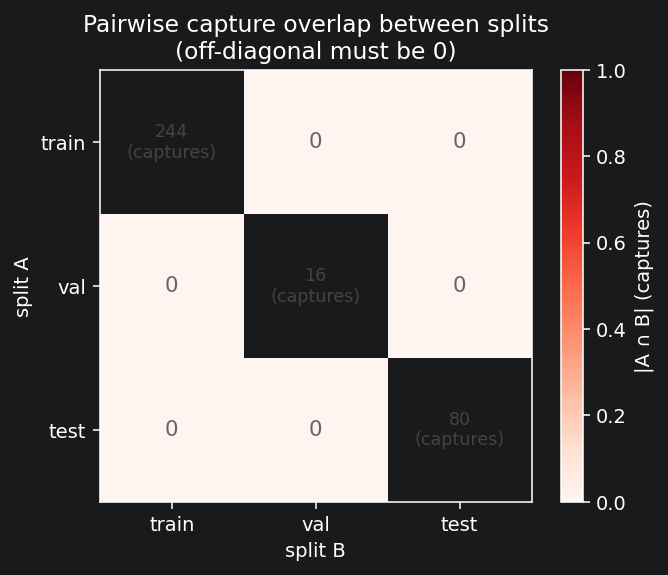

Saved figure to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\figures\validation\capture_overlap_matrix.png


In [3]:
splits = load_split_capture_sets(paths)
mat = capture_overlap_matrix(splits)

print(mat)

fig_dir = paths.repo_root / "figures" / "validation"
fig_dir.mkdir(parents=True, exist_ok=True)

off_diag = mat.values.astype(float).copy()
np.fill_diagonal(off_diag, np.nan)

fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=140)

vmax = max(
    1,
    int(np.nanmax(off_diag)) if np.any(np.isfinite(off_diag)) else 1
)

im = ax.imshow(
    off_diag,
    cmap="Reds",
    vmin=0,
    vmax=vmax
)

for i, a in enumerate(mat.index):
    for j, b in enumerate(mat.columns):
        v = int(mat.iloc[i, j])

        if i == j:
            ax.text(
                j,
                i,
                f"{v}\n(captures)",
                ha="center",
                va="center",
                color="#444",
                fontsize=9
            )
        else:
            color = "white" if v > 0 else "#666"
            ax.text(
                j,
                i,
                f"{v}",
                ha="center",
                va="center",
                color=color,
                fontsize=11
            )

ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns)

ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index)

ax.set_title("Pairwise capture overlap between splits\n(off-diagonal must be 0)")
ax.set_xlabel("split B")
ax.set_ylabel("split A")

plt.colorbar(im, ax=ax, label="|A ∩ B| (captures)")
plt.tight_layout()

out_png = fig_dir / "capture_overlap_matrix.png"

plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved figure to:", out_png)

## 2 · Row-level duplicate-feature scan

In [4]:
df = load_features_dataframe(paths)
feat_cols = model_feature_columns(df)

print(f"{len(feat_cols)} model feature columns; {len(df):,} rows.")

row_hash = hash_feature_rows(df, feat_cols)

work = df[["split", "capture_id", "dataset"]].copy()
work["row_hash"] = row_hash.values

splits_per_hash = work.groupby("row_hash")["split"].nunique()
cross_hashes = splits_per_hash[splits_per_hash > 1].index

cross = work[work["row_hash"].isin(cross_hashes)]

print(
    f"Cross-split duplicate hashes: {len(cross_hashes)}; "
    f"rows involved: {len(cross)}"
)

cross.sort_values("row_hash").head(20)

12 model feature columns; 4,712 rows.
Cross-split duplicate hashes: 0; rows involved: 0


,split,capture_id,dataset,row_hash


## 3 · Threshold provenance

In [5]:
prov = ensure_policy_threshold_provenance(paths)

print("global_policy_fit_split:", prov.get("global_policy_fit_split"))

pd.DataFrame(prov["policies"]).T[["threshold", "fit_split"]] if prov["policies"] else "no policies"

global_policy_fit_split: val


,threshold,fit_split
balanced,0.5,val
flag,0.5,val
strict,0.5,val


## 4 · Preprocessing metadata (fit on train only)

In [6]:
meta = ensure_preprocessing_metadata(paths)

print("fit_split           :", meta.fit_split)
print("transformer_type    :", meta.transformer_type)
print("transformed_splits  :", meta.transformed_splits)
print("feature_columns (n) :", len(meta.feature_columns))

mism = stats_match_train(meta, df)

print("Mismatches vs train :", len(mism))

pd.DataFrame(meta.train_stats).T.head(10)

fit_split           : train
transformer_type    : QuantileTransformer
transformed_splits  : ['train', 'val', 'test']
feature_columns (n) : 9
Mismatches vs train : 0


,mean,std,min,max,n
sz_coef_variation,0.500695,0.198892,-0.175419,1.243830,2817.0
sz_p25_median_ratio,0.700359,0.152213,0.162253,1.173150,2817.0
sz_p75_median_ratio,1.401825,0.296040,0.374364,2.350052,2817.0
sz_iqr_norm_median,0.602392,0.197546,-0.140018,1.417585,2817.0
dispersion_symmetry,-0.008431,0.401762,-1.204993,1.317542,2817.0
direction_balance_bytes,0.000685,0.518785,-1.555244,2.012912,2817.0
direction_balance_packets,0.003503,0.504950,-1.688879,1.663736,2817.0
packet_rate,22.446426,48.203119,0.037758,708.490755,2817.0
byte_rate,6528.348727,17970.673863,5.927953,489842.397930,2817.0


## 5 · Forbidden metadata in model features

In [7]:
violations = []

for col in feat_cols:
    cl = col.lower()

    for sub in FORBIDDEN_FEATURE_SUBSTRINGS:
        if sub in cl:
            violations.append(
                {
                    "column": col,
                    "matched_substring": sub
                }
            )
            break

print(f"{len(violations)} forbidden-substring violations.")

metadata_collisions = set(feat_cols).intersection(METADATA_COLS)

print(f"{len(metadata_collisions)} exact metadata-name collisions.")

violations[:10]

0 forbidden-substring violations.
0 exact metadata-name collisions.


[]

## Summary export

In [8]:
rows = [
    {
        "check_name": "no_capture_overlap_between_splits",
        "status": "PASS" if (mat.values.sum() - np.trace(mat.values)) == 0 else "FAIL",
        "details": f"off-diagonal sum = {int(mat.values.sum() - np.trace(mat.values))}",
        "counts": json.dumps(
            {
                "train": int(mat.loc["train", "train"]),
                "val": int(mat.loc["val", "val"]),
                "test": int(mat.loc["test", "test"])
            }
        )
    },
    {
        "check_name": "no_exact_duplicate_feature_rows_across_splits",
        "status": "PASS" if len(cross_hashes) == 0 else "FAIL",
        "details": f"{len(cross_hashes)} hashes, {len(cross)} rows span >1 split",
        "counts": json.dumps(
            {
                "n_rows": int(len(df)),
                "n_cross_hashes": int(len(cross_hashes)),
                "n_cross_rows": int(len(cross))
            }
        )
    },
    {
        "check_name": "thresholds_are_validation_derived_only",
        "status": "PASS"
        if str(prov.get("global_policy_fit_split", "")).lower() in {"val", "validation"}
        else "FAIL",
        "details": (
            f"global={prov.get('global_policy_fit_split')}, "
            f"policies={list(prov['policies'].keys())}"
        ),
        "counts": json.dumps(
            {
                "n_policies": len(prov["policies"])
            }
        )
    },
    {
        "check_name": "scaler_is_fit_only_on_training_data",
        "status": "PASS" if (meta.fit_split == "train" and not mism) else "FAIL",
        "details": (
            f"fit_split={meta.fit_split}, "
            f"transformer={meta.transformer_type}, "
            f"mismatches={len(mism)}"
        ),
        "counts": json.dumps(
            {
                "n_features": len(meta.feature_columns)
            }
        )
    },
    {
        "check_name": "no_metadata_columns_in_model_features",
        "status": "PASS" if (not violations and not metadata_collisions) else "FAIL",
        "details": f"{len(violations)} substring violations",
        "counts": json.dumps(
            {
                "n_violations": len(violations)
            }
        )
    }
]

summary_dir = paths.repo_root / "artifacts" / "validation"
summary_dir.mkdir(parents=True, exist_ok=True)

(summary_dir / "data_leakage_summary.json").write_text(
    json.dumps(rows, indent=2),
    encoding="utf-8"
)

pd.DataFrame(rows).to_csv(
    summary_dir / "data_leakage_summary.csv",
    index=False
)

pd.DataFrame(rows)

,check_name,status,details,counts
0,no_capture_overlap_between_splits,PASS,off-diagonal sum = 0,"{""train"": 244, ""val"": 16, ""test"": 80}"
1,no_exact_duplicate_feature_rows_across_splits,PASS,"0 hashes, 0 rows span >1 split","{""n_rows"": 4712, ""n_cross_hashes"": 0, ""n_cross..."
2,thresholds_are_validation_derived_only,PASS,"global=val, policies=['balanced', 'flag', 'str...","{""n_policies"": 3}"
3,scaler_is_fit_only_on_training_data,PASS,"fit_split=train, transformer=QuantileTransform...","{""n_features"": 9}"
4,no_metadata_columns_in_model_features,PASS,0 substring violations,"{""n_violations"": 0}"
